In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp 
from sklearn.linear_model import *

### Loading Data

In [106]:
df_bike_counts = pd.read_csv('bike_project_data/bike_counts.csv', sep=',', names=["datetime","station","latitude","longitude","bike_count"], header=0)
df_holidays = pd.read_csv('bike_project_data/danish_holidays.csv', sep=',', names=["date","holiday"], header=0)
df_stations = pd.read_csv('bike_project_data/stations.csv', sep=',', names=["station","latitude","longitude","daily_avg_2021"], header=0)
df_weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', sep=',', names=["datetime","temperature_C","wind_speed_ms","precipitation_mm"], header=0)

In [107]:
station = df_bike_counts["station"]
bike_count = df_bike_counts["bike_count"]
datetime = pd.to_datetime(df_bike_counts["datetime"])

year, month, day, hour, day_name = datetime.dt.year, datetime.dt.month, datetime.dt.day, datetime.dt.hour, datetime.dt.day_name

### Spliting Data - Langebro Station

In [108]:
Station = "Langebro"

df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
df_holidays["datetime"] = pd.to_datetime(df_holidays["date"])
df_holidays["holiday"] = True

# merge bike counts with weather on full datetime
df_merged = pd.merge(df_bike_counts, df_weather, on="datetime", how="left")

# merge with holidays on date only
df_merged["date"] = df_merged["datetime"].dt.date
df_holidays["date"] = df_holidays["datetime"].dt.date

df_merged = pd.merge(df_merged, df_holidays[["date", "holiday"]], on="date", how="left")
df_merged["holiday"] = df_merged["holiday"].fillna(False)

df_merged.ffill(inplace=True)

df_training = df_merged[(df_merged["datetime"].dt.year == 2021) & (df_merged["station"] == Station)].copy()
df_validating = df_merged[(df_merged["datetime"].dt.year == 2022) & (df_merged["station"] == Station)].copy()
df_testing = df_merged[(df_merged["datetime"].dt.year == 2023) & (df_merged["station"] == Station)].copy()

C:\Users\Bruger\AppData\Local\Temp\ipykernel_16468\2602881298.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["holiday"] = df_merged["holiday"].fillna(False)


In [109]:
import numpy as np

def linear_reg(X,y):
    return np.linalg.solve(X.T@X, X.T@y)

def ridge_reg(X,y,lam):
    return np.linalg.solve(X.T@X + lam * np.eye(X.shape[0]), X.T@y)

### Baseline Model - Predicting bike count from hour only

In [110]:
X = np.array(df_training['datetime'].dt.hour).reshape(-1,1) #input
n = X.shape[0]
X = X.reshape(n,-1)
X = np.column_stack([np.ones(n),X])

y = np.array(df_training["bike_count"]).reshape(-1, 1) #target
np.column_stack([X,np.ones(X.shape[0])])

w = linear_reg(X, y)

# R2 = regr.score(X, y)
# m = regr.coef_
# c = regr.intercept_

# def predict_count(h):
#     pred = m*h + c
#     return pred.flatten()

w

array([[148.00573516],
       [  3.60544729]])

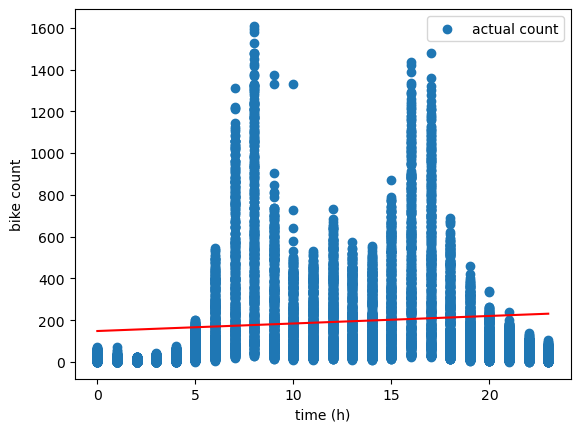

In [111]:
time_eval = np.arange(0, 24, 1)

plt.scatter(df_training["datetime"].dt.hour, df_training["bike_count"], label="actual count")
# plt.plot(time_eval, predict_count(time_eval), label="predicted count", color = "red")

y_pred = X @ w

plt.plot(X[:,1],y_pred, color="red")

plt.xlabel("time (h)")
plt.ylabel('bike count')
plt.legend()
plt.show()

### Improved Model - Predicting bike count from cyclical hour

In [112]:
df_training["h_sin"] = np.sin(2 * np.pi * df_training["datetime"].dt.hour.values/ 24)
df_training["h_cos"] = np.cos(2 * np.pi * df_training["datetime"].dt.hour.values/ 24)

n = X.shape[0]

X = np.column_stack([np.ones(n),df_training["h_sin"], df_training["h_cos"]]) #input
y = np.array(df_training["bike_count"]).reshape(-1, 1) #target

# regr = LinearRegression()
# regr.fit(X, y)


w = linear_reg(X,y)


y_pred = X @ w

# R2 = regr.score(X, y)

def predict_count_2(h):
    sin_h = np.sin(2 * np.pi * h / 24)
    cos_h = np.cos(2 * np.pi * h / 24)
    X_pred = np.column_stack([sin_h, cos_h])
    return regr.predict(X_pred).flatten()

# R2
y_pred
# df_training["datetime"]
w

array([[ 189.468379  ],
       [ -15.90282132],
       [-160.63203881]])

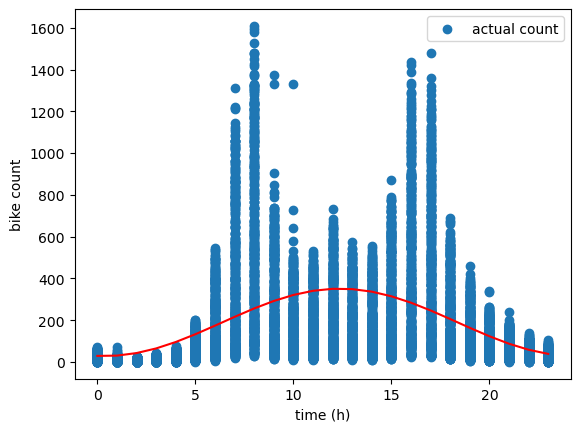

In [113]:
time_eval = np.arange(0, 24, 1)
n = time_eval.shape[0]
XX = np.column_stack([np.ones(n),np.sin(2 * np.pi * time_eval/ 24), np.cos(2 * np.pi * time_eval/ 24)]) #input


plt.scatter(df_training["datetime"].dt.hour, df_training["bike_count"], label="actual count")
# plt.plot(time_eval, predict_count_2(time_eval), label="predicted count", color = "red")
plt.plot(time_eval, XX @ w, color="red")
plt.xlabel("time (h)")
plt.ylabel('bike count')
plt.legend()
plt.show()

### Accounting for 2 peaks per day, weekend, public holiday, temp

In [114]:
df_training["is_weekend"] = df_training["datetime"].dt.dayofweek >= 5
df_training["is_holiday"] = df_training["holiday"] == True

df_training["temp1"] = df_training["temperature_C"]
# df_training["temp2"] = df_training["temperature_C"] ** 2

df_training["h_sin1"] = np.sin(2 * np.pi * df_training["datetime"].dt.hour / 24)
df_training["h_cos1"] = np.cos(2 * np.pi * df_training["datetime"].dt.hour / 24)

df_training["h_sin2"] = np.sin(2 * np.pi * df_training["datetime"].dt.hour / 12)
df_training["h_cos2"] = np.cos(2 * np.pi * df_training["datetime"].dt.hour / 12)

n = df_training.shape[0]

X = np.column_stack([np.ones(n),
                     df_training["h_sin1"], 
                     df_training["h_cos1"], 
                     df_training["h_sin2"], 
                     df_training["h_cos2"], 
                     df_training["is_weekend"], 
                     df_training["is_holiday"], 
                     df_training["temp1"],
                    #  df_training["temp2"]
                     ]) #input

y = np.array(df_training["bike_count"]).reshape(-1, 1) #target

w = linear_reg(X,y)

def predict_count_3(h, temp, is_weekend=False, is_holiday=False):
    sin1_h = np.sin(2 * np.pi * h / 24)
    cos1_h = np.cos(2 * np.pi * h / 24)
    sin2_h = np.sin(2 * np.pi * h / 12)
    cos2_h = np.cos(2 * np.pi * h / 12)

    is_weekend_arr = np.full(len(h), is_weekend, dtype=float)
    is_holiday_arr = np.full(len(h), is_holiday, dtype=float)
    temp1_arr = np.full(len(h), temp, dtype=float)
    temp2_arr = np.full(len(h), temp, dtype=float)
    
    X_pred = np.column_stack([sin1_h, cos1_h, sin2_h, cos2_h, is_weekend_arr, is_holiday_arr, temp1_arr, temp2_arr])
    return regr.predict(X_pred).flatten()

# R2
w

array([[ 125.43079082],
       [ -14.51097504],
       [-130.05458022],
       [ -20.39712545],
       [ -88.6244113 ],
       [-108.54097771],
       [-103.49185507],
       [  12.36235466]])

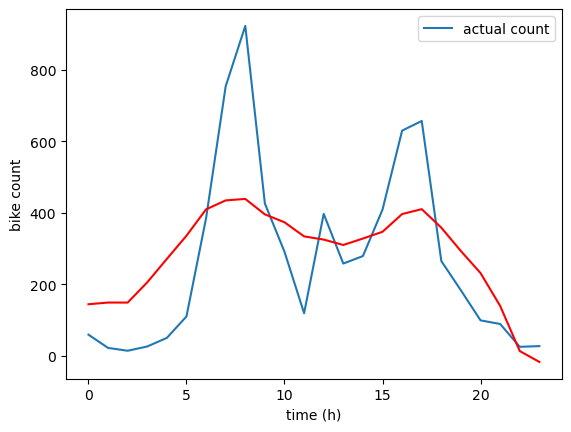

In [164]:
time_eval = np.arange(0, 24, 1)

df_validating["is_weekend"] = df_validating["datetime"].dt.dayofweek >= 5
df_validating["is_holiday"] = df_validating["holiday"] == True

df_validating["temp1"] = df_validating["temperature_C"]
# df_validating["temp2"] = df_validating["temperature_C"] ** 2

df_validating["h_sin1"] = np.sin(2 * np.pi * df_validating["datetime"].dt.hour / 24)
df_validating["h_cos1"] = np.cos(2 * np.pi * df_validating["datetime"].dt.hour / 24)

df_validating["h_sin2"] = np.sin(2 * np.pi * df_validating["datetime"].dt.hour / 12)
df_validating["h_cos2"] = np.cos(2 * np.pi * df_validating["datetime"].dt.hour / 12)

XX = np.column_stack([np.ones(n),
                     df_validating["h_sin1"], 
                     df_validating["h_cos1"], 
                     df_validating["h_sin2"], 
                     df_validating["h_cos2"], 
                     df_validating["is_weekend"], 
                     df_validating["is_holiday"], 
                     df_validating["temp1"],
                    #  df_validating["temp2"]
                     ]) #input

day = 200

plt.plot(df_validating["datetime"].dt.hour.values[24 * day: 24 * day + 24], df_validating["bike_count"][24 * day: 24 * day + 24], label="actual count")
# plt.plot(time_eval, predict_count_3(time_eval, 25, False, False), label="predicted count", color = "red")
plt.plot(df_validating["datetime"].dt.hour.values[24 * day: 24 * day + 24], (XX @ w)[24 * day : 24 * day + 24],color="red")

plt.xlabel("time (h)")
plt.ylabel('bike count')
plt.legend()
plt.show()


In [207]:
def calculate_error_MSE(X,w,y_true):
    y_pred = np.maximum((X @ w).flatten(),0)
    RMSE = np.sqrt(np.sum((y_pred - y_true)**2))
    return RMSE

print(calculate_error_MSE(XX,w,df_validating["bike_count"]))

16216.973985574277


In [208]:
(XX @ w)[24 * day : 24 * day + 24].reshape(-1)

array([145.62996433, 154.69773259, 152.19467752, 211.03224615,
       274.90010585, 339.93621698, 413.44356183, 437.45413522,
       443.76710638, 381.46820758, 356.68920157, 177.50546087,
       335.05020211, 326.22437383, 339.05018722, 338.37652985,
       406.5818325 , 421.63727876, 367.35888958, 279.12103582,
       240.38037745, 148.22008594,  47.61834155, -31.07903369])

2566900.5402578637


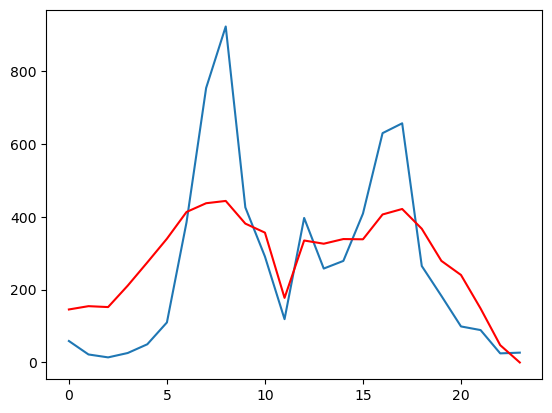

In [209]:
def build_system(df):
    df["temp1"] = df["temperature_C"]
    df["h_sin1"] = np.sin(2 * np.pi * df["datetime"].dt.hour / 24)
    df["h_cos1"] = np.cos(2 * np.pi * df["datetime"].dt.hour / 24)

    df["h_sin2"] = np.sin(2 * np.pi * df["datetime"].dt.hour / 12)
    df["h_cos2"] = np.cos(2 * np.pi * df["datetime"].dt.hour / 12)

    df["d_sin"] = np.sin(2 * np.pi * df["datetime"].dt.day / 365)
    df["d_cos"] = np.cos(2 * np.pi * df["datetime"].dt.day / 365)




    n = df.shape[0]

    X = np.column_stack([np.ones(n),
                        df["h_sin1"], 
                        df["h_cos1"], 
                        df["h_sin2"], 
                        df["h_cos2"], 
                        df["h_sin3"], 
                        df["h_cos3"], 
                        df["is_weekend"], 
                        df["is_holiday"], 
                        df["temp1"],
                        df["precipitation_mm"],
                        ])
    y = np.array(df_training["bike_count"]).reshape(-1, 1) #target
    return X,y


X,y = build_system(df_training)

w = linear_reg(X,y)

time_eval = np.arange(0, 24, 1)

XX, yy = build_system(df_validating)


print(calculate_error_MSE(XX,w,yy))

day = 200
plt_days = 5
plt.plot(df_validating["datetime"].dt.hour.values[24 * day: 24 * day + 24], df_validating["bike_count"][24 * day: 24 * day + 24], label="actual count")
plt.plot(df_validating["datetime"].dt.hour.values[24 * day: 24 * day + 24], np.maximum((XX @ w)[24 * day : 24 * day + 24],0),color="red")

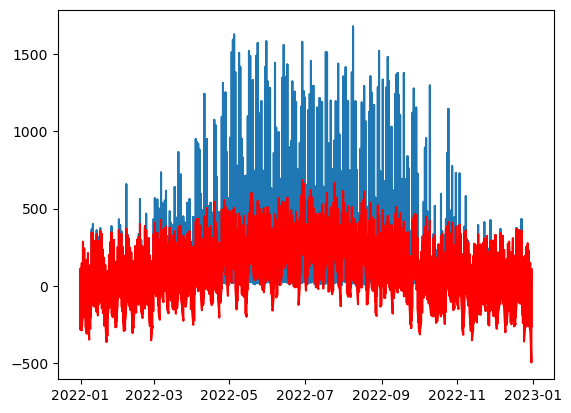

In [186]:
plt.plot(df_validating["datetime"].dt.date.values, df_validating["bike_count"], label="actual count")
plt.plot(df_validating["datetime"].dt.date.values, (XX @ w),color="red")

#### Applying Ridge Regression

In [118]:
regr = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000, 5000, 10000], cv=5)
regr.fit(X, y)

print(f"Best alpha: {regr.alpha_}")
print(f"R2: {regr.score(X, y)}")

Best alpha: 5000.0
R2: 0.4235362151840998
